# Retail Sales Visualization

This notebook creates business-focused visualizations from the KPI tables prepared during the previous stage.

Each chart answers a specific business question and includes a short interpretation of the result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from matplotlib.ticker import FuncFormatter

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

reports_table_dir = (project_root/ "reports"/ "tables")

figures_dir = (project_root/ "reports"/ "figures")

figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables directory: {reports_table_dir}")
print(f"Figures directory: {figures_dir}")

Project root: c:\Users\ASUS\Python_workspace\retail_sales_insights
Tables directory: c:\Users\ASUS\Python_workspace\retail_sales_insights\reports\tables
Figures directory: c:\Users\ASUS\Python_workspace\retail_sales_insights\reports\figures


## 1. Load Analysis Tables

In [4]:
monthly_kpis = pd.read_csv(reports_table_dir / "monthly_kpis.csv",parse_dates=["invoice_month"])

country_kpis = pd.read_csv(reports_table_dir / "country_kpis.csv")

product_kpis = pd.read_csv(reports_table_dir / "product_kpis.csv")

customer_kpis = pd.read_csv(reports_table_dir / "customer_kpis.csv",parse_dates=["first_purchase","last_purchase",])

order_kpis = pd.read_csv(reports_table_dir / "order_kpis.csv",parse_dates=["order_date"])

In [5]:
tables = {
    "Monthly KPIs": monthly_kpis,
    "Country KPIs": country_kpis,
    "Product KPIs": product_kpis,
    "Customer KPIs": customer_kpis,
    "Order KPIs": order_kpis,
}

for table_name, dataframe in tables.items():
    print(
        f"{table_name}: "
        f"{dataframe.shape[0]:,} rows, "
        f"{dataframe.shape[1]} columns"
    )

Monthly KPIs: 13 rows, 8 columns
Country KPIs: 38 rows, 9 columns
Product KPIs: 4,158 rows, 10 columns
Customer KPIs: 4,338 rows, 10 columns
Order KPIs: 19,960 rows, 8 columns


## 2. Validate the Tables

In [6]:
assert not monthly_kpis.empty
assert not country_kpis.empty
assert not product_kpis.empty
assert not customer_kpis.empty
assert not order_kpis.empty

assert {"invoice_month","revenue","orders"}.issubset(monthly_kpis.columns)

assert {"country","revenue"}.issubset(country_kpis.columns)

assert {"description", "revenue"}.issubset(product_kpis.columns)

assert {"customer_id","revenue"}.issubset(customer_kpis.columns)

assert {"invoice_no","order_revenue"}.issubset(order_kpis.columns)

print("All tables are ready for visualization.")

All tables are ready for visualization.


## 3. Chart Formatting Functions

In [7]:
def format_currency_axis(value: float,position: int,) -> str:
    """Format currency values for chart axes."""

    if abs(value) >= 1_000_000:
        return f"£{value / 1_000_000:.1f}M"

    if abs(value) >= 1_000:
        return f"£{value / 1_000:.0f}K"

    return f"£{value:.0f}"

In [8]:
def format_number_axis(value: float,position: int,) -> str:
    """Format large whole numbers for chart axes."""

    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"

    if abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"

    return f"{value:.0f}"

In [9]:
print(format_currency_axis(1_500_000, 0))
print(format_currency_axis(25_000, 0))
print(format_number_axis(125_000, 0))

£1.5M
£25K
125.0K


## 4. Monthly Revenue Trend

In [10]:
monthly_plot_df = (monthly_kpis.sort_values("invoice_month").copy())

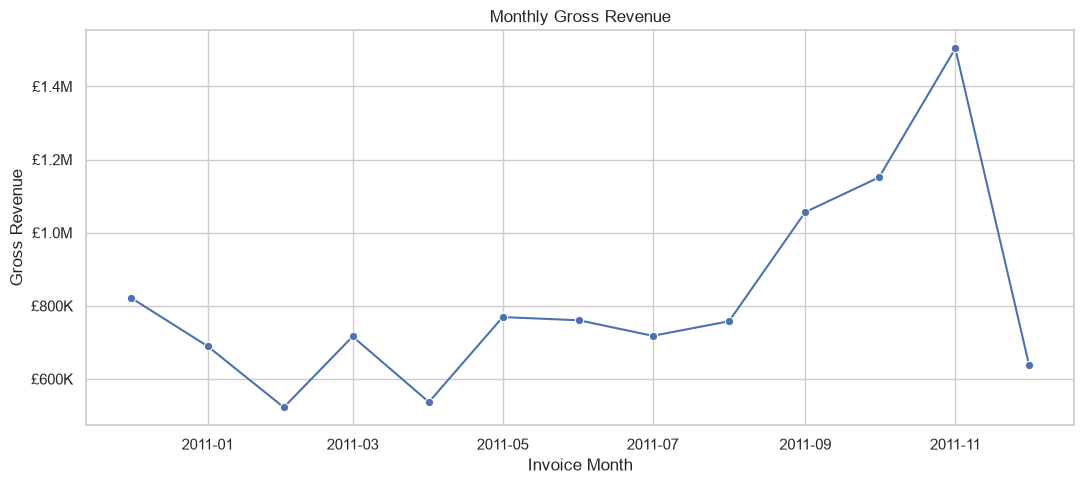

In [11]:
fig, ax = plt.subplots(figsize=(11, 5),)

sns.lineplot(
    data=monthly_plot_df,
    x="invoice_month",
    y="revenue",
    marker="o",
    ax=ax,
)

ax.set_title("Monthly Gross Revenue")
ax.set_xlabel("Invoice Month")
ax.set_ylabel("Gross Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(format_currency_axis))
fig.tight_layout()

monthly_revenue_path = (figures_dir/ "monthly_revenue.png")

fig.savefig(monthly_revenue_path,dpi=200,bbox_inches="tight",)

plt.show()


In [12]:
monthly_revenue_path.exists()

True

In [13]:
best_month = monthly_plot_df.loc[monthly_plot_df["revenue"].idxmax()]

print(
    f"The highest recorded monthly revenue was "
    f"£{best_month['revenue']:,.2f} in "
    f"{best_month['invoice_month']:%Y-%m}."
)

The highest recorded monthly revenue was £1,503,866.78 in 2011-11.


### Interpretation

Revenue reached its highest recorded value in **2011-11** at approximately **£1,503,867**.

The first and final months may contain incomplete data, so they should not be
compared directly with full months without checking the dataset date range.

## 5. Monthly Completed Orders

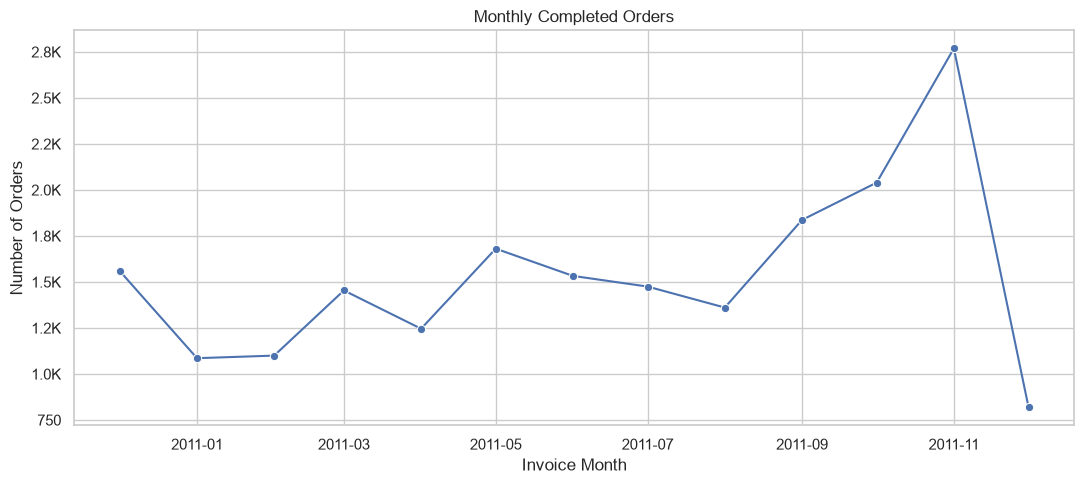

In [14]:
fig, ax = plt.subplots(figsize=(11, 5),)

sns.lineplot(
    data=monthly_plot_df,
    x="invoice_month",
    y="orders",
    marker="o",
    ax=ax,
)

ax.set_title("Monthly Completed Orders")
ax.set_xlabel( "Invoice Month")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(FuncFormatter(format_number_axis))
fig.tight_layout()

monthly_orders_path = (figures_dir/ "monthly_orders.png")

fig.savefig(monthly_orders_path, dpi=200, bbox_inches="tight",)

plt.show()


In [15]:
highest_order_month = monthly_plot_df.loc[monthly_plot_df["orders"].idxmax()]

print(
    f"The highest completed order count was "
    f"{highest_order_month['orders']:,.0f} in "
    f"{highest_order_month['invoice_month']:%Y-%m}."
)

The highest completed order count was 2,769 in 2011-11.


### Interpretation

The largest number of completed orders occurred in **2011-11**.

Comparing this chart with monthly revenue helps determine whether revenue changes were mainly caused by order volume, larger order values, or both.

## 6. Top Countries by Revenue

In [16]:
top_countries = country_kpis.nlargest(10, "revenue").sort_values("revenue").copy()

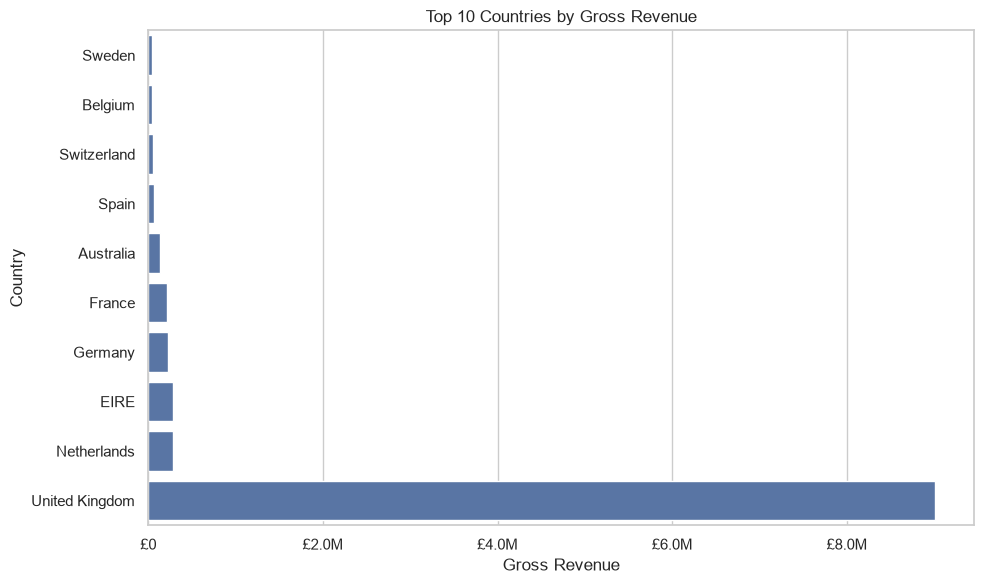

In [17]:
fig, ax = plt.subplots(figsize=(10, 6),)

sns.barplot(
    data=top_countries,
    x="revenue",
    y="country",
    ax=ax,
)

ax.set_title("Top 10 Countries by Gross Revenue")
ax.set_xlabel("Gross Revenue")
ax.set_ylabel("Country")
ax.xaxis.set_major_formatter(FuncFormatter(format_currency_axis))
fig.tight_layout()

top_countries_path = (figures_dir/ "top_countries_revenue.png")

fig.savefig(top_countries_path, dpi=200, bbox_inches="tight",)
plt.show()


In [18]:
top_country = country_kpis.iloc[0]

print(
    f"{top_country['country']} generated "
    f"£{top_country['revenue']:,.2f}, representing "
    f"{top_country['revenue_share_pct']:.2f}% "
    f"of gross revenue."
)

United Kingdom generated £9,001,744.09, representing 84.59% of gross revenue.


### Interpretation

The UK was the largest market, generating approximately **£9,001,744** and
representing **84.59%** of total gross revenue.

A very high share would indicate geographic concentration. The business could
protect its main market while also developing other countries to reduce
dependence on one location.

In [19]:
top_international_countries = country_kpis[country_kpis["country"]!= "United Kingdom"].nlargest(10, "revenue").sort_values("revenue").copy()


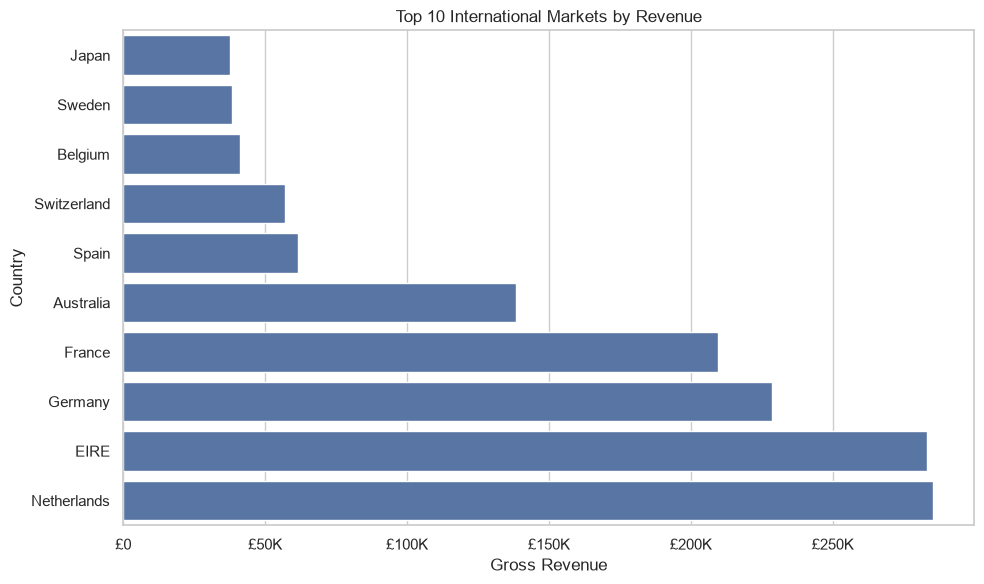

In [20]:
fig, ax = plt.subplots(figsize=(10, 6),)

sns.barplot(
    data=top_international_countries,
    x="revenue",
    y="country",
    ax=ax,
)

ax.set_title("Top 10 International Markets by Revenue")
ax.set_xlabel("Gross Revenue")
ax.set_ylabel("Country")
ax.xaxis.set_major_formatter(FuncFormatter(format_currency_axis))
fig.tight_layout()

international_path = (figures_dir/ "top_international_markets.png")
fig.savefig(international_path,dpi=200,bbox_inches="tight",)

plt.show()


## 7. Top Products by Revenue

In [21]:
top_products = product_kpis.nlargest(10, "revenue").copy()

top_products["product_label"] = (
    top_products["description"]
    .astype(str)
    .str.title()
    .str.slice(0, 40)
)

top_products = top_products.sort_values("revenue")

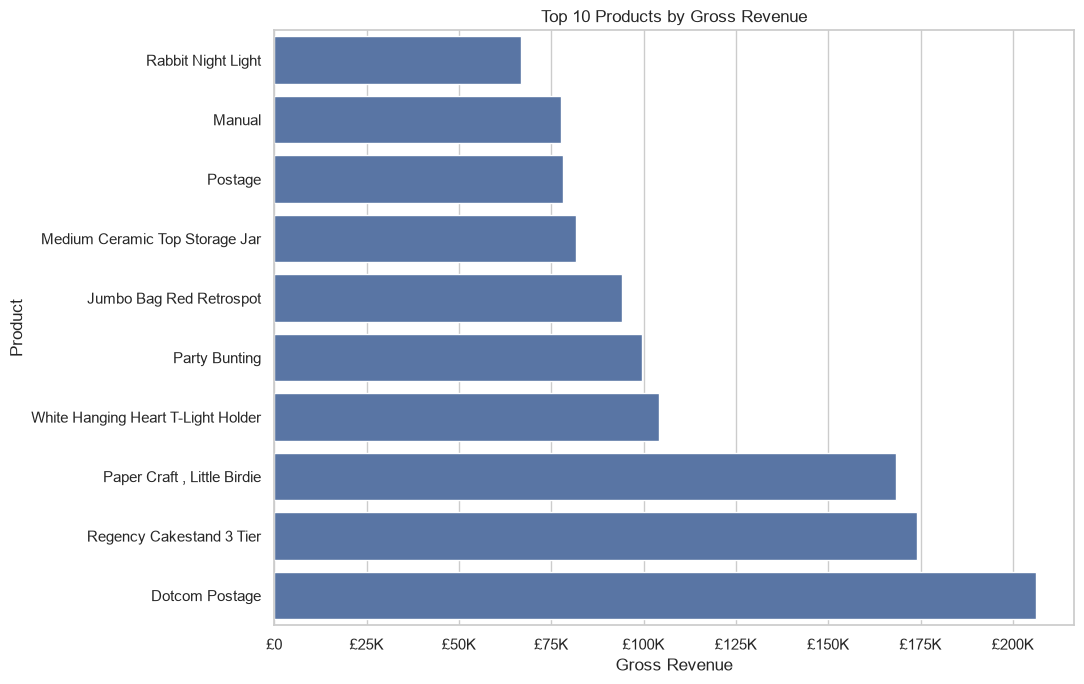

In [22]:
fig, ax = plt.subplots(figsize=(11, 7),)

sns.barplot(
    data=top_products,
    x="revenue",
    y="product_label",
    ax=ax,
)

ax.set_title("Top 10 Products by Gross Revenue")
ax.set_xlabel("Gross Revenue")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(FuncFormatter(format_currency_axis))
fig.tight_layout()

top_products_path = (figures_dir/ "top_products_revenue.png")
fig.savefig(top_products_path,dpi=200,bbox_inches="tight",)

plt.show()


In [23]:
top_product = product_kpis.iloc[0]

print(
    f"The highest-revenue product was "
    f"{top_product['description']}, generating "
    f"£{top_product['revenue']:,.2f}."
)

The highest-revenue product was DOTCOM POSTAGE, generating £206,248.77.


### Interpretation

**DOTCOM POSTAGE** generated the highest gross revenue at approximately **£206,249**.

The highest-revenue products may not be the products with the largest number
of units sold. Revenue depends on both sales volume and selling price.

## 8. Order Value Distribution

In [24]:
order_kpis["order_revenue"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])

count     19960.000000
mean        533.171884
std        1780.412288
min           0.380000
50%         303.300000
75%         493.462500
90%         938.391000
95%        1585.921000
99%        4821.165400
max      168469.600000
Name: order_revenue, dtype: float64

In [25]:
order_revenue_limit = (order_kpis["order_revenue"].quantile(0.99))

print(f"99th percentile: "f"£{order_revenue_limit:,.2f}")

99th percentile: £4,821.17


In [26]:
order_plot_df = order_kpis[order_kpis["order_revenue"]<= order_revenue_limit].copy()

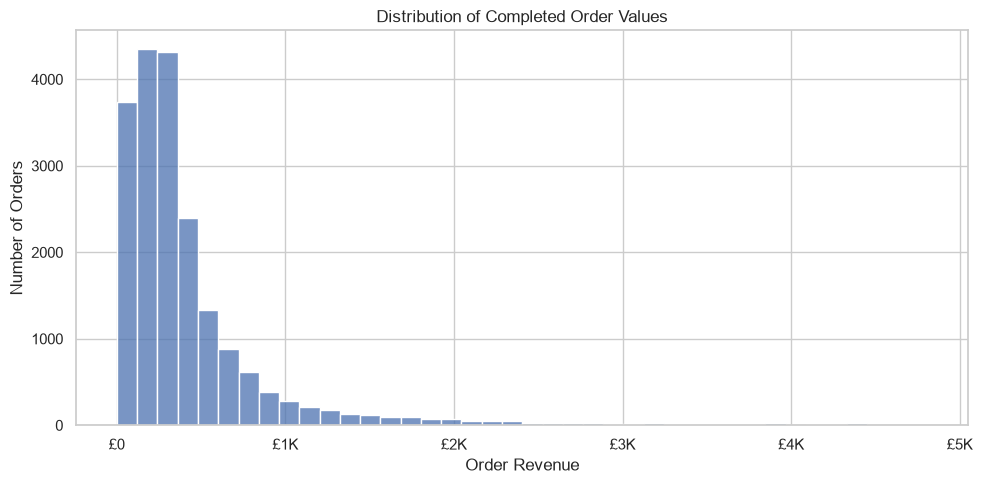

In [27]:
fig, ax = plt.subplots(figsize=(10, 5),)

sns.histplot(
    data=order_plot_df,
    x="order_revenue",
    bins=40,
    ax=ax,
)

ax.set_title("Distribution of Completed Order Values")
ax.set_xlabel("Order Revenue")
ax.set_ylabel("Number of Orders")
ax.xaxis.set_major_formatter(FuncFormatter(format_currency_axis))
fig.tight_layout()

order_distribution_path = (figures_dir/ "order_value_distribution.png")
fig.savefig(order_distribution_path,dpi=200,bbox_inches="tight",)

plt.show()



In [28]:
mean_order_value = (order_kpis["order_revenue"].mean())
median_order_value = (order_kpis["order_revenue"].median())

print(f"Mean order value: "f"£{mean_order_value:,.2f}")
print(f"Median order value: "f"£{median_order_value:,.2f}")

Mean order value: £533.17
Median order value: £303.30


### Interpretation

Most completed orders are concentrated at the lower end of the order-value range, while a smaller number of large orders increase the average.

The chart displays orders up to the 99th percentile so the typical distribution is easier to see. No records were removed from the actual analysis.

## 9. Customer Revenue Distribution

In [29]:
customer_revenue_limit = (customer_kpis["revenue"].quantile(0.99))

print(f"Customer revenue 99th percentile: " f"£{customer_revenue_limit:,.2f}")

Customer revenue 99th percentile: £19,780.49


In [30]:
customer_plot_df = customer_kpis[customer_kpis["revenue"]<= customer_revenue_limit].copy()

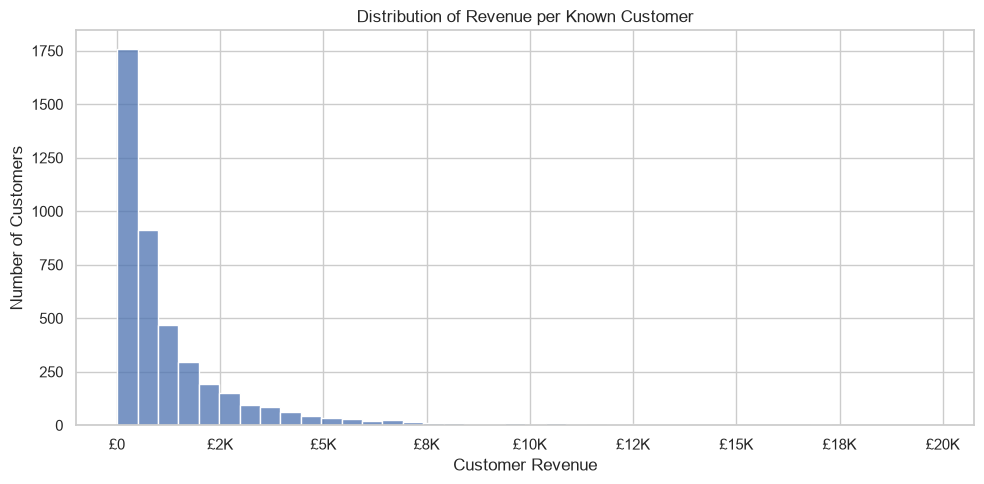

In [31]:
fig, ax = plt.subplots(figsize=(10, 5),)

sns.histplot(
    data=customer_plot_df,
    x="revenue",
    bins=40,
    ax=ax,
)

ax.set_title("Distribution of Revenue per Known Customer")
ax.set_xlabel( "Customer Revenue")
ax.set_ylabel("Number of Customers")
ax.xaxis.set_major_formatter(FuncFormatter(format_currency_axis))
fig.tight_layout()

customer_distribution_path = (figures_dir/ "customer_revenue_distribution.png")
fig.savefig(customer_distribution_path,dpi=200,bbox_inches="tight",)

plt.show()

In [32]:
mean_customer_revenue = (customer_kpis["revenue"].mean())
median_customer_revenue = (customer_kpis["revenue"].median())

print(f"Mean known-customer revenue: " f"£{mean_customer_revenue:,.2f}")
print( f"Median known-customer revenue: " f"£{median_customer_revenue:,.2f}")

Mean known-customer revenue: £2,048.69
Median known-customer revenue: £668.57


### Interpretation

Customer spending is not evenly distributed. Most known customers generaterelatively modest revenue, while a smaller group contributes much larger amounts.

This supports performing customer segmentation on Day 6 to identify valuable, loyal, new, and at-risk customer groups.

In [33]:
figure_summary = pd.DataFrame({
    "figure": [
        "monthly_revenue.png",
        "monthly_orders.png",
        "top_countries_revenue.png",
        "top_products_revenue.png",
        "order_value_distribution.png",
        "customer_revenue_distribution.png",
    ],
    "business_question": [
        "How does gross revenue change over time?",
        "How does completed order volume change over time?",
        "Which countries generate the most revenue?",
        "Which products generate the most revenue?",
        "What does a typical completed order value look like?",
        "How is revenue distributed among known customers?",
    ],
})
pd.set_option('display.max_colwidth', None)

figure_summary

,figure,business_question
0,monthly_revenue.png,How does gross revenue change over time?
1,monthly_orders.png,How does completed order volume change over time?
2,top_countries_revenue.png,Which countries generate the most revenue?
3,top_products_revenue.png,Which products generate the most revenue?
4,order_value_distribution.png,What does a typical completed order value look like?
5,customer_revenue_distribution.png,How is revenue distributed among known customers?


In [34]:
expected_figures = [
    figures_dir / "monthly_revenue.png",
    figures_dir / "monthly_orders.png",
    figures_dir / "top_countries_revenue.png",
    figures_dir / "top_products_revenue.png",
    figures_dir / "order_value_distribution.png",
    figures_dir / "customer_revenue_distribution.png",
]

In [35]:
for figure_path in expected_figures:
    print(f"{figure_path.name}: " f"{figure_path.exists()}")

monthly_revenue.png: True
monthly_orders.png: True
top_countries_revenue.png: True
top_products_revenue.png: True
order_value_distribution.png: True
customer_revenue_distribution.png: True


## 10. Conclusion

The KPI tables were converted into six business-focused visualizations.

The charts show monthly revenue and order trends, the leading countries and
products, and the distribution of order and customer revenue. The
distribution charts were limited to the 99th percentile for display purposes
so typical values could be seen clearly, but the original data was not
removed or changed.

These visualizations will support the final customer segmentation and
business recommendations.